In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Dataset/powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis = 1)
y = df['PE']

In [7]:
# Split Our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape

(7654, 4)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [10]:
import torch
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [12]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loder = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loder = DataLoader(test_dataset, batch_size=32)

In [15]:
train_dataset[0]

(tensor([ 0.7481,  0.7201, -0.3266, -0.4971]), tensor([442.7500]))

### Deep Learning

In [16]:
## Define Our ANN Model

In [17]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [18]:
import torch.optim as optim

model = ANN()

# Loss, Optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [19]:
type(model)

__main__.ANN

In [20]:
model

ANN(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=1, bias=True)
  )
)

## Train ANN

In [21]:
train_loses = []
value_loses = []
epochs = 100

best_val_loss = float("inf")

for epochs in range(epochs):
    model.train()
    running_lose = 0.0  # Save the total Training Loss for 1 epoch

    for xb, yb in train_loder:
        # xb = features of each batch
        # yb = labels of each bath
        optimizer.zero_grad()
        
        outputs = model(xb) # forword prop... Predicted Outputs for this batch
        loss = crietrion(outputs, yb) # Compute loss
        loss.backward() # back prop... Compute gradients
        optimizer.step() # Params Update
        
        running_lose += loss.item() # loss is a tensor ==> py float
        
    epoch_train_loss = running_lose / len(train_loder)
    train_loses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loder:
            outputs = model(xb)
            loss = crietrion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loder)
    value_loses.append(epoch_val_loss)
    print(f'epoch {epochs + 1}/{epochs} ==> Train Loss = {epoch_train_loss} & {epoch_val_loss}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/0 ==> Train Loss = 205716.65162760418 & 203017.06380208334
epoch 2/1 ==> Train Loss = 193139.0689453125 & 177280.83645833333
epoch 3/2 ==> Train Loss = 149163.52073567707 & 117332.64557291666
epoch 4/3 ==> Train Loss = 87252.25013020834 & 61222.151692708336
epoch 5/4 ==> Train Loss = 45606.594466145834 & 32998.71731770833
epoch 6/5 ==> Train Loss = 26571.182071940104 & 20538.910384114584
epoch 7/6 ==> Train Loss = 17997.916573079427 & 14828.191235351562
epoch 8/7 ==> Train Loss = 13379.190120442709 & 11007.953776041666
epoch 9/8 ==> Train Loss = 9745.460972086588 & 7800.150402832031
epoch 10/9 ==> Train Loss = 6824.880258178711 & 5387.200406901042
epoch 11/10 ==> Train Loss = 4721.943276977539 & 3719.413077799479
epoch 12/11 ==> Train Loss = 3323.002214050293 & 2651.602634684245
epoch 13/12 ==> Train Loss = 2434.609868367513 & 1966.931537882487
epoch 14/13 ==> Train Loss = 1808.6181482950847 & 1472.0862314860026
epoch 15/14 ==> Train Loss = 1347.0872126261393 & 1098.15886484781

In [22]:
import matplotlib.pyplot as plt

In [23]:
loss_df = pd.DataFrame({
    "train_loss": train_loses,
    "valid_loss": value_loses
})
loss_df

,train_loss,valid_loss
0,205716.651628,203017.063802
1,193139.068945,177280.836458
2,149163.520736,117332.645573
3,87252.250130,61222.151693
4,45606.594466,32998.717318
...,...,...
95,20.425408,19.625181
96,20.548405,19.581779
97,20.730863,18.891125
98,20.448960,18.888286


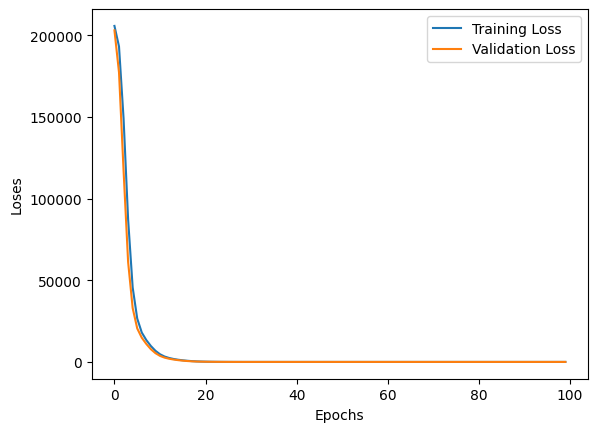

In [24]:
plt.plot(loss_df['train_loss'], label='Training Loss')
plt.plot(loss_df['valid_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loses")
plt.legend()
plt.show()

In [25]:
# Loading the Best Model
torch.load("best_model.pt")

C:\Users\luxlu\AppData\Local\Temp\ipykernel_2532\2787345981.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_model.pt")


OrderedDict([('model.0.weight',
              tensor([[-0.0382, -0.1082, -0.2894, -0.6978],
                      [ 0.2036, -0.0969, -0.1778, -0.5799],
                      [ 0.6484,  0.7926,  0.4212,  0.2840],
                      [-0.7197, -0.7302,  0.2924,  0.2980],
                      [ 0.1093,  0.7957, -0.3892,  0.6449],
                      [-0.9870, -0.9045,  0.1446, -0.0485]])),
             ('model.0.bias',
              tensor([3.1798, 3.0509, 3.4545, 3.8240, 2.8474, 2.8347])),
             ('model.2.weight',
              tensor([[ 1.9549,  2.0279,  2.2524,  2.0648,  2.1546,  2.0650],
                      [ 1.7748,  2.1956,  2.0745,  2.1132,  2.0319,  1.7970],
                      [ 0.0803, -0.2232, -0.2342,  0.1991,  0.2410, -0.3091],
                      [ 2.1877,  2.3165,  2.3048,  2.2566,  2.2478,  1.6540],
                      [ 2.3337,  2.3646,  2.4284,  2.0231,  1.8131,  1.6694],
                      [ 1.5676,  1.7509,  1.5814,  2.0000,  1.6412,  1.7798]])),

In [26]:
model.load_state_dict(torch.load("best_model.pt"))

C:\Users\luxlu\AppData\Local\Temp\ipykernel_2532\349716640.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [27]:
# Evaluation

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss = crietrion(test_pred, y_test_tensor)

print("Training MSE", train_mse_loss.item())
print("Testing MSE", test_mse_loss.item())

Training MSE 20.173988342285156
Testing MSE 18.512056350708008


In [29]:
from sklearn.metrics import r2_score

print(f"R^2 Score: {r2_score(y_test, test_pred)}")

R^2 Score: 0.9353051448203308


In [30]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.747711,433.27
1,436.396881,438.16
2,461.492157,458.42
3,476.770782,480.82
4,434.722351,441.41
...,...,...
1909,451.321442,456.70
1910,431.035858,438.04
1911,467.739990,467.80
1912,430.406708,437.14
